In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
events_timeline = pd.read_csv('../data/geopolitical_events_timeline.csv')
oil_geopolitics = pd.read_csv('../data/oil_geopolitics_dataset_2010_2026.csv')

# Analyzing Data Types
First, I take an initial look at the dataset and look at the data types of each column.

In [3]:
events_timeline.head()


,date,event_type,event_description,event_severity
0,2010-04-20,disaster,Deepwater Horizon oil spill,7
1,2011-02-15,war,Libyan Civil War begins,9
2,2011-03-19,war,NATO intervention in Libya,9
3,2012-01-23,sanctions,EU embargo on Iranian oil imports,8
4,2014-03-18,annexation,Russia annexes Crimea,8


In [4]:
events_timeline.dtypes

date                   str
event_type             str
event_description      str
event_severity       int64
dtype: object

Everything looks okay except for the `date` column. I convert it to a `DateTime` object so we can query values such as the **day**, **month**, and **year** of each date for more advanced queries.

In [5]:
corrected_dates = events_timeline['date']

# %Y-%m-%d is the format followed in the data (e.g. 2011-03-19) is March 19, 2011
corrected_dates = pd.to_datetime(corrected_dates, format='%Y-%m-%d')

# Change the date column to the corrected dates column
events_timeline['date'] = corrected_dates

Quick sanity check

In [6]:
events_timeline.dtypes

date                 datetime64[us]
event_type                      str
event_description               str
event_severity                int64
dtype: object

This allows us to make queries like the one below to check for all events that occurred in 2011.

In [7]:
events_timeline[events_timeline['date'].dt.year == 2011]

,date,event_type,event_description,event_severity
1,2011-02-15,war,Libyan Civil War begins,9
2,2011-03-19,war,NATO intervention in Libya,9


Or this one that allows us to check for events that occurred during December.

In [8]:
events_timeline[events_timeline['date'].dt.month == 12]

,date,event_type,event_description,event_severity
21,2022-12-05,sanctions,G7 price cap on Russian oil,7


# Visualization
Because the events dataset was not that dirty to begin with, we can move on visualizing the data. Let's look at our columns again.

In [9]:
events_timeline.head()

,date,event_type,event_description,event_severity
0,2010-04-20,disaster,Deepwater Horizon oil spill,7
1,2011-02-15,war,Libyan Civil War begins,9
2,2011-03-19,war,NATO intervention in Libya,9
3,2012-01-23,sanctions,EU embargo on Iranian oil imports,8
4,2014-03-18,annexation,Russia annexes Crimea,8


We can move left from right. First, let's look at the `date` column. I want to know what year was the most eventful in terms of oil geopolitics.

In [ ]:
# Get years and occurrences per year, in ascending order by year.
years = events_timeline['date'].dt.year.value_counts().sort_index()
years

date
2010    1
2011    2
2012    1
2014    2
2015    1
2016    3
2017    1
2018    1
2019    1
2020    3
2021    2
2022    4
2023    2
2024    4
2025    4
2026    3
Name: count, dtype: int64

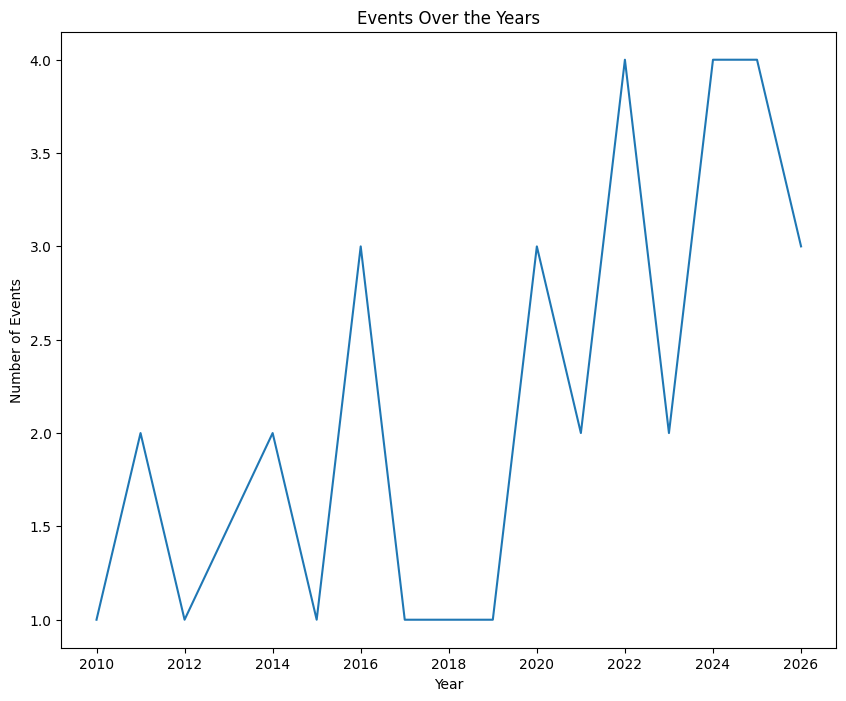

In [24]:
fig, ax = plt.subplots(figsize=(10, 8))
ax.plot(years)

plt.xlabel('Year')
plt.ylabel('Number of Events')
plt.title('Events Over the Years')

plt.show();

From the line graph, we can see that the in the dataset, the least eventful year was 2018, with 1 event occurring. While the most eventful year is a tie between 2022 and 2024, with 4 events each. An interesting trend is that from the year 2020 onwards the number of conflicts fluctuates greatly. With the highest number of events happening on the years **2022**, **2024**, and **2025**. Let's look at events that happened from 2022 - 2026.

In [33]:
events_timeline.loc[(events_timeline['date'].dt.year >= 2022) & (events_timeline['date'].dt.year <= 2026)]

,date,event_type,event_description,event_severity
18,2022-02-24,war,Russia invades Ukraine,10
19,2022-03-08,sanctions,US bans Russian oil imports,9
20,2022-06-01,sanctions,EU oil embargo on Russia,8
21,2022-12-05,sanctions,G7 price cap on Russian oil,7
22,2023-04-02,opec,OPEC+ announces surprise production cuts,9
23,2023-10-07,war,Israel-Hamas war begins,9
24,2024-01-12,conflict,Red Sea shipping attacks escalate,8
25,2024-04-14,conflict,Iran launches drone attack on Israel,9
26,2024-08-26,blockade,Libya eastern administration halts oil production,8
27,2024-10-01,conflict,Expanded Red Sea tanker attacks,8


Now we look at the `event_type` column. We want to know what was the most frequent type of event. Let's visualize this using a bar graph.

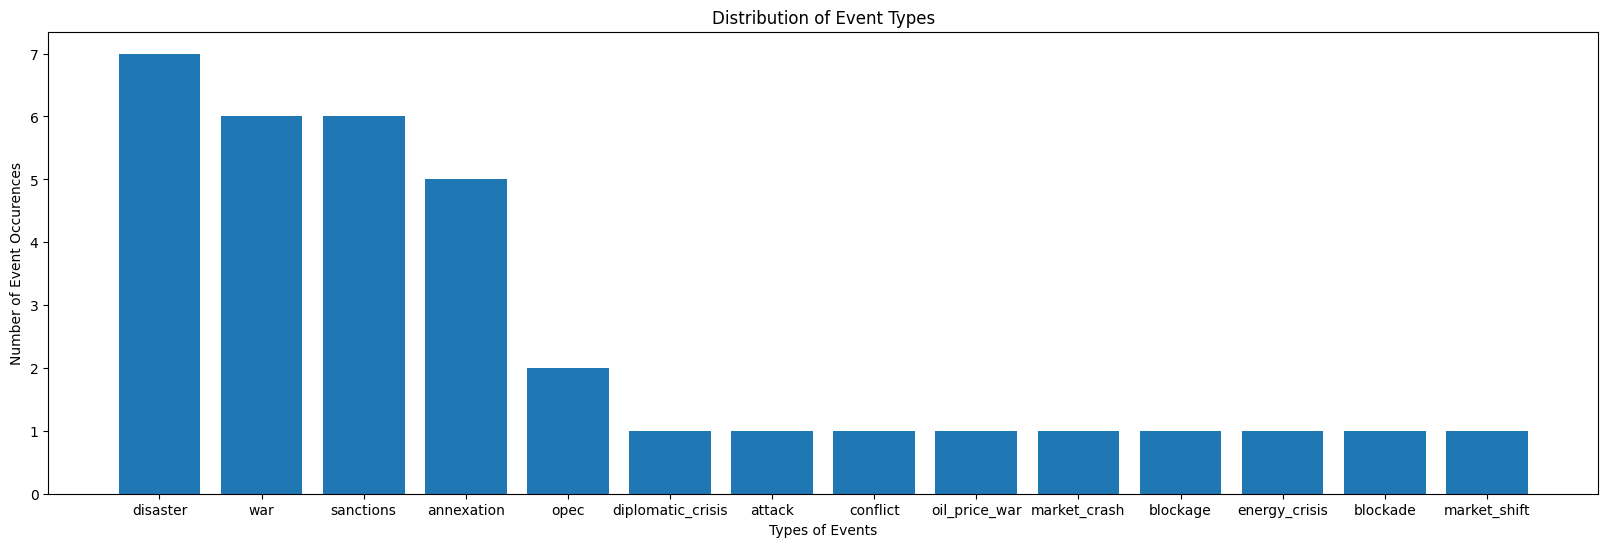

In [ ]:
labels = events_timeline['event_type'].unique()
sizes = events_timeline['event_type'].value_counts()

fig, ax = plt.subplots(figsize=(20, 6))
plt.bar(labels, sizes)

plt.xlabel("Types of Events")
plt.ylabel("Number of Event Occurences")
plt.title("Distribution of Event Types")

plt.show();

`disaster` is the most common type of event, occurring a total of 7 times, `war` and `sanctions` are in second with 6 times for both. `annexation` and `opec` come in third and fourth, with 5 and 2 occurrences respectively. Everything else is tied for last with 1 occurrence of each.

However, although some events occur more frequently than others, this is **not** enough to say that one type of event is destructive than the others.

Let's move on to the `event_description` column. Looking at the columns we can see that the name of a country / party is often involved. Because of current events, let's look at the involvement of countries such as the **United States**, **Israel**, and **Iran**. Let's also look at **OPEC** or the Organization of the Petroleum Exporting Countries. 

In [25]:
columns = ['date', 'event_type', 'event_description', 'event_severity']
events_focus = events_timeline[columns]

In [26]:
events_focus[events_focus['event_description'].str.contains("US")]

,date,event_type,event_description,event_severity
11,2018-05-08,sanctions,US withdraws from Iran nuclear deal,8
13,2020-01-03,conflict,US kills Iranian General Qasem Soleimani,9
19,2022-03-08,sanctions,US bans Russian oil imports,9
32,2026-02-28,conflict,US-Israel strikes on Iranian infrastructure,10


In [27]:
events_focus[events_focus['event_description'].str.contains("Israel")]

,date,event_type,event_description,event_severity
23,2023-10-07,war,Israel-Hamas war begins,9
25,2024-04-14,conflict,Iran launches drone attack on Israel,9
32,2026-02-28,conflict,US-Israel strikes on Iranian infrastructure,10


In [28]:
events_focus[events_focus['event_description'].str.contains("Iran")]

,date,event_type,event_description,event_severity
3,2012-01-23,sanctions,EU embargo on Iranian oil imports,8
7,2016-01-16,sanctions,Iran nuclear sanctions lifted,6
11,2018-05-08,sanctions,US withdraws from Iran nuclear deal,8
13,2020-01-03,conflict,US kills Iranian General Qasem Soleimani,9
25,2024-04-14,conflict,Iran launches drone attack on Israel,9
31,2025-11-18,sanctions,Expanded Iran oil sanctions,7
32,2026-02-28,conflict,US-Israel strikes on Iranian infrastructure,10


In [29]:
events_focus[events_focus['event_description'].str.contains("OPEC")]

,date,event_type,event_description,event_severity
5,2014-11-27,opec,OPEC maintains production despite falling prices,9
8,2016-09-28,opec,OPEC Algiers agreement on production cuts,8
9,2016-11-30,opec,First OPEC+ production cut agreement,8
22,2023-04-02,opec,OPEC+ announces surprise production cuts,9
29,2025-06-10,opec,OPEC+ announces additional production cuts,8
33,2026-03-01,opec,OPEC+ extends voluntary production cuts,8


We can see that a lot of events involve multiple countries. Another observation is that events involving OPEC are usually related to oil production, rather than some external event.

Now let's look at the distribution of `event_severity`, and get some descriptive statistics.

In [30]:
events_timeline['event_severity'].describe()

count    35.000000
mean      8.285714
std       1.126458
min       6.000000
25%       8.000000
50%       8.000000
75%       9.000000
max      10.000000
Name: event_severity, dtype: float64

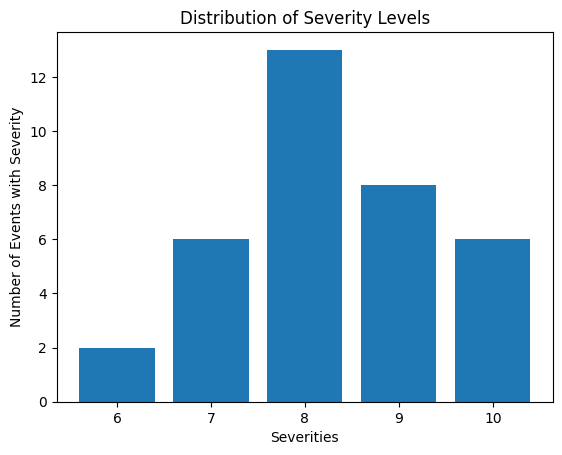

In [90]:
severity_count = events_timeline['event_severity'].unique()
severity_count.sort()

severities = events_timeline['event_severity'].value_counts().sort_index()

plt.bar(severity_count, severities)
plt.xlabel("Severities")
plt.ylabel("Number of Events with Severity")
plt.title("Distribution of Severity Levels")

plt.show()

A severity score of 8 is the most common, while a severity score of 6 is the rarest.

Overall, the `geopolitical_events_timeline` dataset did not have any dirty data, I just had to change the datatype of the `date` column to support more robust querying. I learned a lot from this dataset. Mainly:

1. From the year 2020 onward, the number of events are only increasing. This can be attributed to rising global tensions, as well as policy changes from OPEC.
2. A lot of the events involve conflicts between multiple countries. Although `war` is the most common type of event in the dataset, in recent years `conflict` made more of an appearance.